# CodeAlpha — Task 4: Disease Prediction from Medical Data

**Objective:** Predict the likelihood of disease from patient diagnostic data.

**Dataset:** Breast Cancer Wisconsin (Diagnostic) — a real medical dataset from the UCI ML Repository, built into scikit-learn. 569 patients, 30 diagnostic features, binary target (malignant vs benign).

**Approach:** Classification using Logistic Regression, Random Forest, SVM, and XGBoost, compared on Precision, Recall, F1-Score, and ROC-AUC.

**Pipeline:** Data → EDA → Train/Test Split → Scale → Train 4 models → Evaluate → Compare → Feature Importance.

*CodeAlpha Machine Learning Internship.*

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve)

sns.set_style("whitegrid")
np.random.seed(42)
print("Libraries loaded.")

Libraries loaded.


## 2. Dataset

The Breast Cancer Wisconsin dataset describes cell-nucleus characteristics measured from
digitized images of breast masses. Each row is a patient; the target is whether the tumor
is **malignant (0)** or **benign (1)**.

In [2]:
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['diagnosis'] = data.target   # 0 = malignant, 1 = benign

print("Shape:", df.shape)
print("Target classes:", dict(zip([0, 1], data.target_names)))
df.head()

Shape: (569, 31)
Target classes: {0: np.str_('malignant'), 1: np.str_('benign')}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 3. Exploratory Data Analysis

diagnosis
1    357
0    212
Name: count, dtype: int64

Class balance:
diagnosis
1    0.627
0    0.373
Name: proportion, dtype: float64


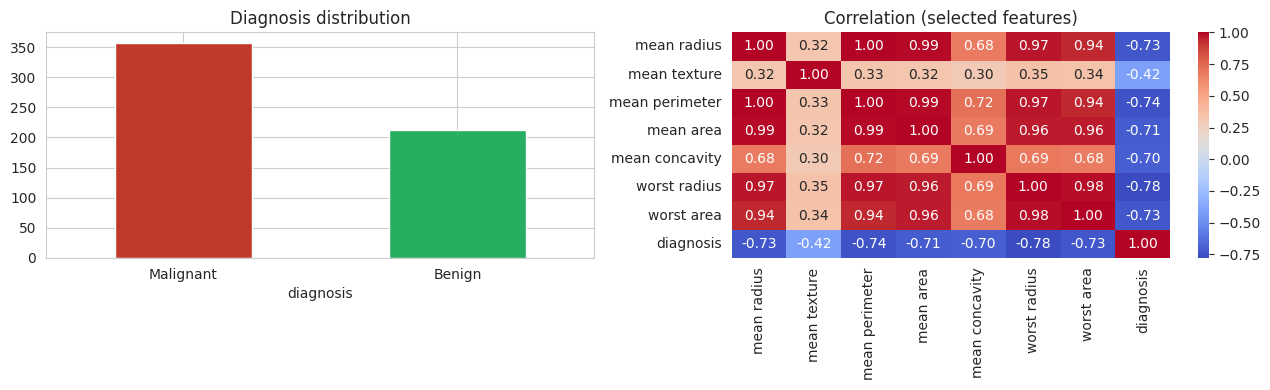

In [3]:
print(df['diagnosis'].value_counts())
print()
print("Class balance:")
print(df['diagnosis'].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df['diagnosis'].value_counts().plot(kind='bar', ax=ax[0], color=['#c0392b', '#27ae60'])
ax[0].set_title("Diagnosis distribution")
ax[0].set_xticklabels(['Malignant', 'Benign'], rotation=0)

# Correlation of a few key features with the target
key = ['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean concavity', 'worst radius', 'worst area', 'diagnosis']
sns.heatmap(df[key].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax[1])
ax[1].set_title("Correlation (selected features)")
plt.tight_layout(); plt.show()

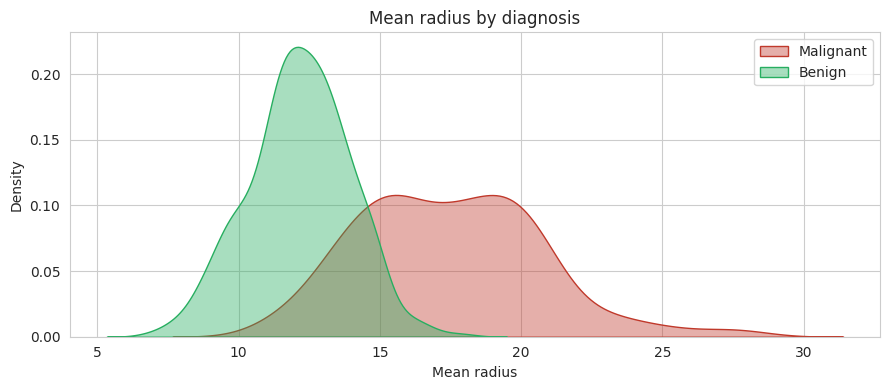

In [4]:
# Distribution of a key diagnostic feature by class
plt.figure(figsize=(9, 4))
for label, name, color in [(0, 'Malignant', '#c0392b'), (1, 'Benign', '#27ae60')]:
    sns.kdeplot(df[df['diagnosis'] == label]['mean radius'],
                label=name, fill=True, alpha=0.4, color=color)
plt.title("Mean radius by diagnosis"); plt.xlabel("Mean radius"); plt.legend()
plt.tight_layout(); plt.show()

## 4. Train/Test Split + Scaling

In [5]:
X = df.drop(columns='diagnosis')
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} patients | Test: {X_test.shape[0]} patients")

Train: 455 patients | Test: 114 patients


## 5. Train Four Models

Logistic Regression and SVM need scaled features; Random Forest and XGBoost don't,
so each model gets the input form it works best with.

In [6]:
models = {
    "Logistic Regression": (LogisticRegression(max_iter=5000), True),
    "Random Forest":       (RandomForestClassifier(n_estimators=200, random_state=42), False),
    "SVM":                 (SVC(probability=True, random_state=42), True),
    "XGBoost":             (XGBClassifier(n_estimators=200, learning_rate=0.1,
                                          eval_metric='logloss', random_state=42), False),
}

results = {}
for name, (model, use_scaled) in models.items():
    Xtr = X_train_s if use_scaled else X_train
    Xte = X_test_s  if use_scaled else X_test
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]
    results[name] = {
        "model": model, "y_pred": y_pred, "y_proba": y_proba,
        "Precision": precision_score(y_test, y_pred),
        "Recall":    recall_score(y_test, y_pred),
        "F1":        f1_score(y_test, y_pred),
        "ROC-AUC":   roc_auc_score(y_test, y_proba),
    }
    print(f"{name} trained.")

Logistic Regression trained.


Random Forest trained.
SVM trained.
XGBoost trained.


## 6. Evaluation — Metrics Comparison

In [7]:
metrics_df = pd.DataFrame({
    name: {k: round(v, 3) for k, v in r.items()
           if k in ['Precision', 'Recall', 'F1', 'ROC-AUC']}
    for name, r in results.items()
}).T
print(metrics_df)
metrics_df

                     Precision  Recall     F1  ROC-AUC
Logistic Regression      0.986   0.986  0.986    0.995
Random Forest            0.959   0.972  0.966    0.993
SVM                      0.986   0.986  0.986    0.995
XGBoost                  0.946   0.972  0.959    0.994


,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.986,0.986,0.986,0.995
Random Forest,0.959,0.972,0.966,0.993
SVM,0.986,0.986,0.986,0.995
XGBoost,0.946,0.972,0.959,0.994


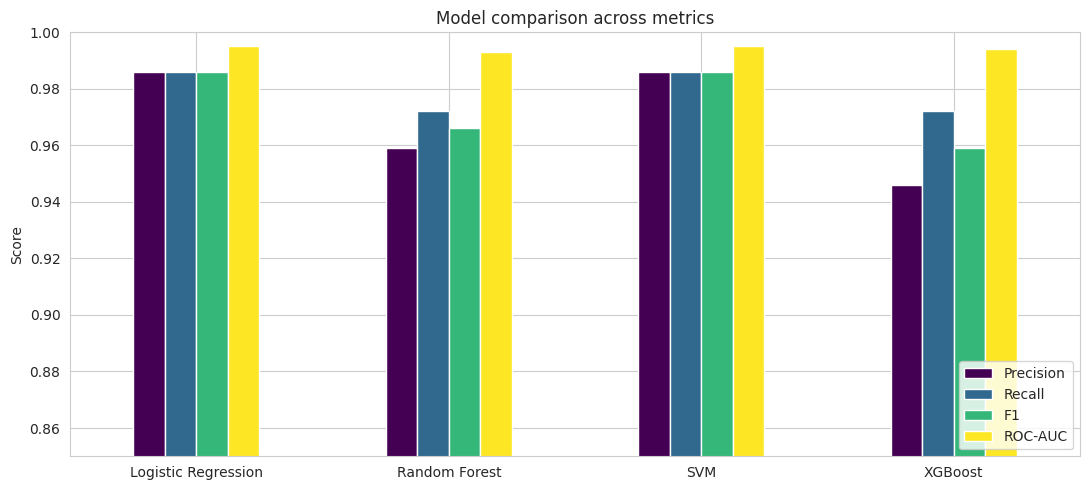

In [8]:
metrics_df.plot(kind='bar', figsize=(11, 5), colormap='viridis')
plt.title("Model comparison across metrics")
plt.ylabel("Score"); plt.ylim(0.85, 1.0); plt.xticks(rotation=0)
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

## 7. Confusion Matrix + Classification Report (best model)

In a medical context, **recall on the malignant class matters most** — a missed malignant
case (false negative) is the most dangerous error, so we read the confusion matrix with that
in mind.

Best model by F1: Logistic Regression

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



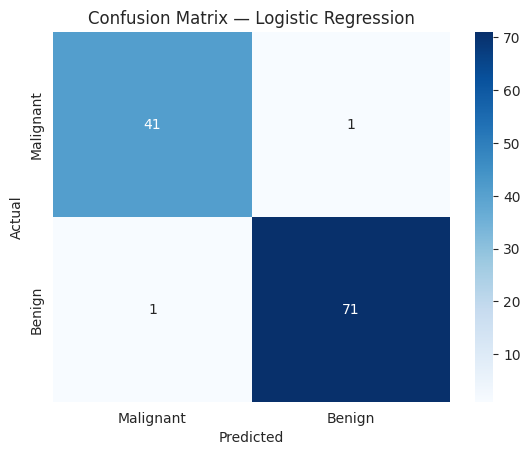

In [9]:
best_name = metrics_df['F1'].idxmax()
best = results[best_name]
print(f"Best model by F1: {best_name}\n")
print(classification_report(y_test, best['y_pred'],
      target_names=['Malignant', 'Benign']))

cm = confusion_matrix(y_test, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.title(f"Confusion Matrix — {best_name}")
plt.ylabel("Actual"); plt.xlabel("Predicted"); plt.show()

## 8. ROC Curves

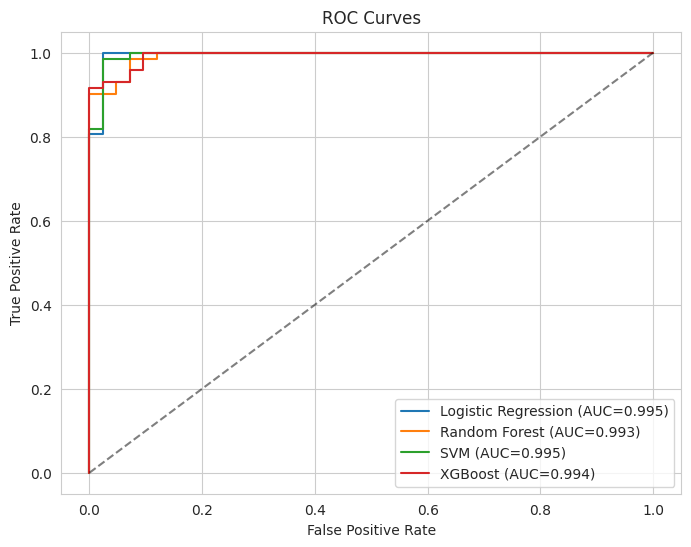

In [10]:
plt.figure(figsize=(8, 6))
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={r['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves"); plt.legend(loc='lower right'); plt.show()

## 9. Feature Importance (Random Forest)

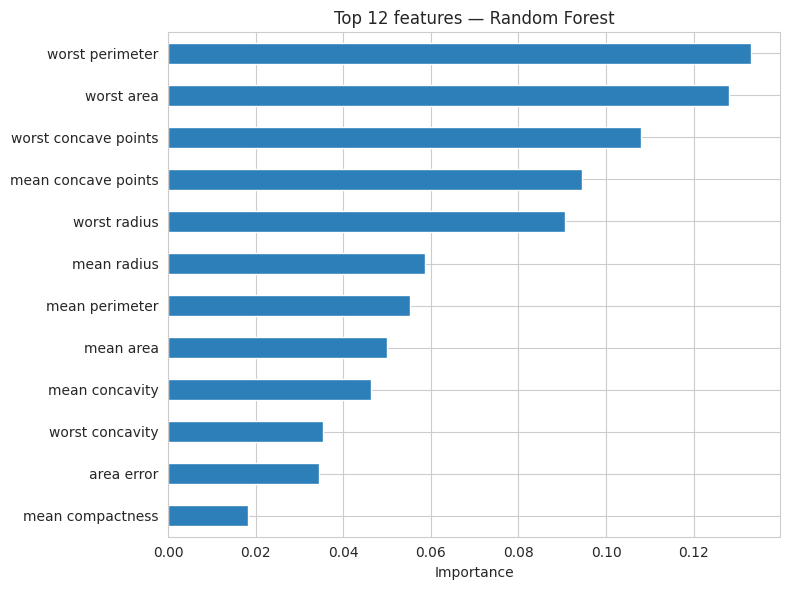

worst perimeter         0.133
worst area              0.128
worst concave points    0.108
mean concave points     0.094
worst radius            0.091
mean radius             0.059
mean perimeter          0.055
mean area               0.050
mean concavity          0.046
worst concavity         0.035
area error              0.034
mean compactness        0.018
dtype: float64


In [11]:
rf = results['Random Forest']['model']
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values().tail(12)
imp.plot(kind='barh', figsize=(8, 6), color='#2c7fb8')
plt.title("Top 12 features — Random Forest")
plt.xlabel("Importance"); plt.tight_layout(); plt.show()
print(imp.sort_values(ascending=False).round(3))

## 10. Conclusion

We built a disease-prediction classifier on the Breast Cancer Wisconsin dataset, comparing
four algorithms — Logistic Regression, Random Forest, SVM, and XGBoost — on Precision, Recall,
F1-Score, and ROC-AUC.

All models perform strongly because the diagnostic features are highly informative, but the
evaluation emphasizes **recall on malignant cases**: in screening, a false negative (missing a
malignant tumor) is the costliest error. The most important features — worst-case radius,
perimeter, and concavity measurements — match clinical intuition about tumor characteristics.

**Important note:** this is an educational project. A real diagnostic tool would require
clinical validation, far more data, and regulatory approval before any medical use.

**Next steps:** cross-validation, hyperparameter tuning, and threshold adjustment to maximize
malignant-case recall for a screening setting.

*Task 4 complete — CodeAlpha Machine Learning Internship.*